# Lab 04: Thực hành các phép lọc
a. Lọc trung bình, trung bình theo k giá trị gần nhất, trung vị với W(3x3), W(7x7), W(11x11), ngưỡng 5, 10, 20, k = 3, 7, 11
b. Cuộn với nhân Gauss 2 chiều (3 bộ tham số)
c. Phát hiện chuyển động trong video giao thông

## a. Lọc ảnh xám

In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

path = "ava.jpeg"

Height: 414
Width: 736


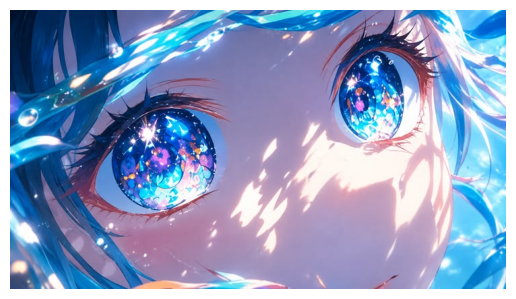

In [2]:
img_original = cv.imread(path)
if img_original is None:
    raise FileNotFoundError(f"Không đọc được ảnh: {path}")

h, w = img_original.shape[:2]
print("Height:", h)
print("Width:", w)

img_original = cv.cvtColor(img_original, cv.COLOR_BGR2RGB)
plt.imshow(img_original)
plt.axis("off")
plt.show()

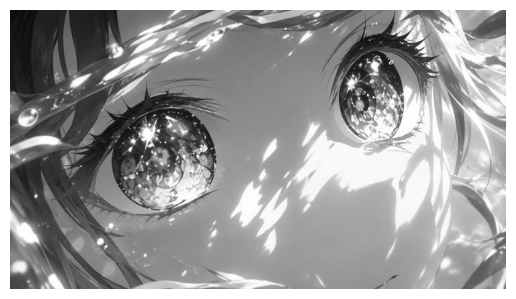

In [3]:
img_gray = cv.imread(path, cv.IMREAD_GRAYSCALE)
plt.imshow(img_gray, cmap="gray")
plt.axis("off")
plt.show()

### Lọc trung bình

In [4]:
def trung_binh(x0, y0, I, W):
    h, w = W[0], W[1]
    dy, dx = h // 2, w // 2
    x, y = x0 - dx, y0 - dy

    total = 0.0
    for i in range(y, y + h):
        for j in range(x, x + w):
            total += int(I[i, j])

    return round(total / (w * h))


def loc_trung_binh(I, W=(3, 3), theta=1):
    wh, ww = W[0], W[1]
    dy, dx = wh // 2, ww // 2

    I_kq = np.copy(I)
    for y in range(dy, I.shape[0] - dy):
        for x in range(dx, I.shape[1] - dx):
            avp = trung_binh(x, y, I, W)
            if abs(int(I[y, x]) - int(avp)) > theta:
                I_kq[y, x] = avp

    return I_kq

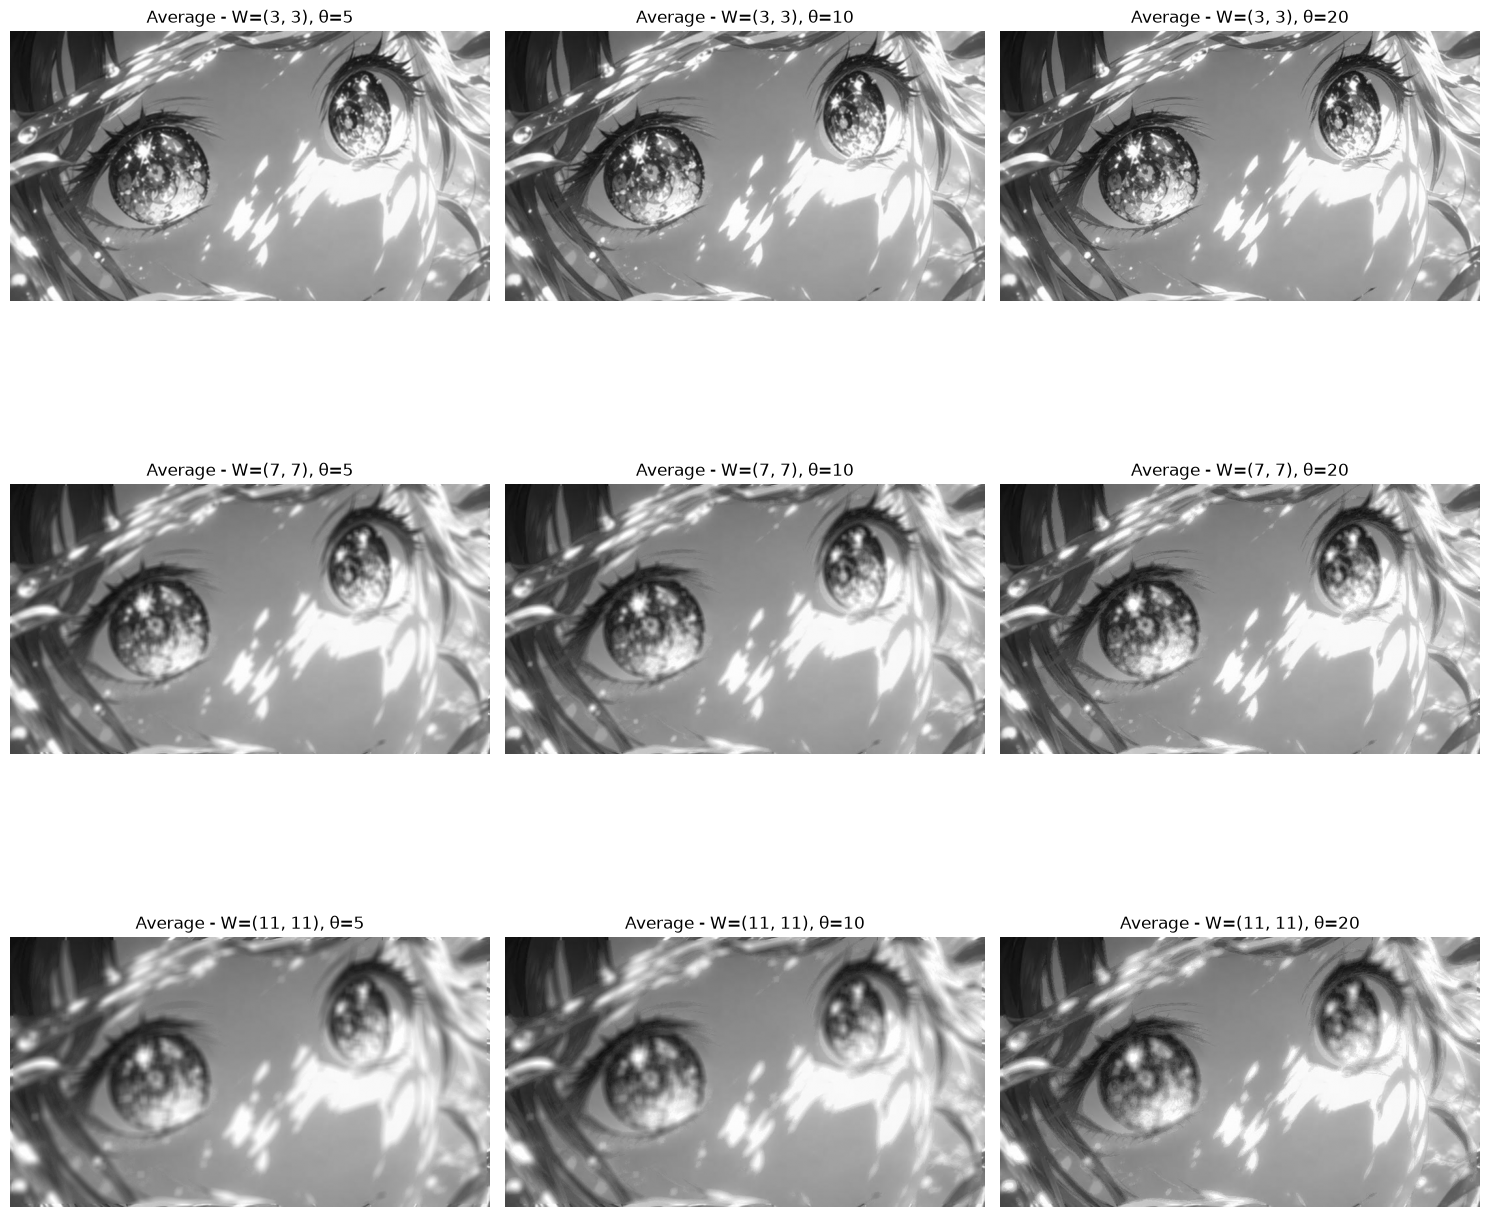

In [5]:
Ws = [(3, 3), (7, 7), (11, 11)]
thetas = [5, 10, 20]

plt.figure(figsize=(15, 15))
i = 1
for W in Ws:
    for theta in thetas:
        kq = loc_trung_binh(img_gray, W=W, theta=theta)
        plt.subplot(3, 3, i)
        plt.imshow(kq, cmap="gray", vmin=0, vmax=255)
        plt.title(f"Average - W={W}, θ={theta}")
        plt.axis("off")
        i += 1

plt.tight_layout()
plt.show()

Với ngưỡng 5, 10, 20, ảnh gần như không mờ vì chỉ những pixel lệch trung bình cục bộ hơn θ mới bị thay.
Chạy thêm θ = 0 (thay mọi pixel bằng trung bình) để thấy rõ hiệu ứng làm mờ.

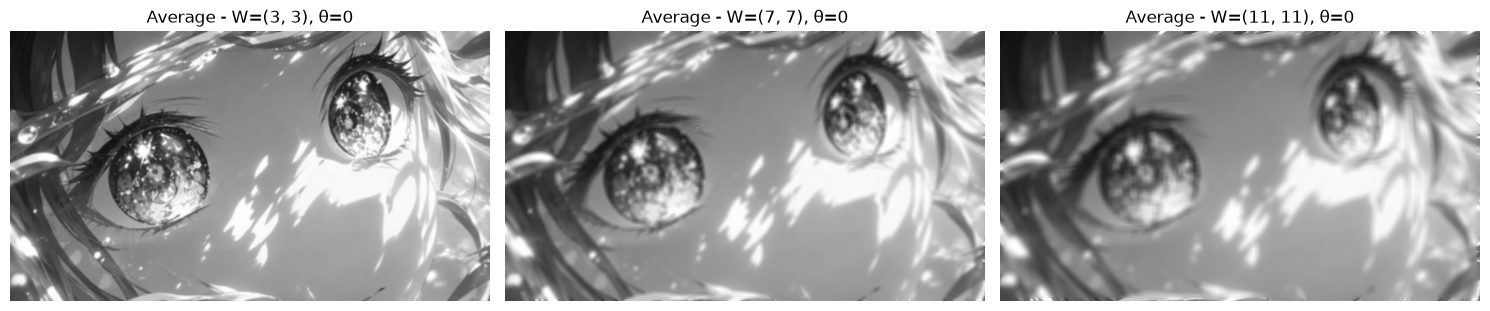

In [6]:
plt.figure(figsize=(15, 5))
for i, W in enumerate(Ws, 1):
    kq = loc_trung_binh(img_gray, W=W, theta=0)
    plt.subplot(1, 3, i)
    plt.imshow(kq, cmap="gray", vmin=0, vmax=255)
    plt.title(f"Average - W={W}, θ=0")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Lọc trung bình theo k giá trị gần nhất

In [7]:
def trung_binh_k_gan_nhat(x0, y0, I, W, k):
    h, w = W[0], W[1]
    dy, dx = h // 2, w // 2
    x, y = x0 - dx, y0 - dy

    center = int(I[y0, x0])
    values = []

    for i in range(y, y + h):
        for j in range(x, x + w):
            value = int(I[i, j])
            distance = abs(value - center)
            values.append((distance, value))

    # sắp xếp theo khoảng cách tăng dần, lấy k giá trị gần nhất
    values.sort(key=lambda t: t[0])
    k_values = [value for distance, value in values[:k]]

    return round(sum(k_values) / k)


def loc_trung_binh_k_gan_nhat(I, W=(3, 3), k=3, theta=1):
    wh, ww = W[0], W[1]
    dy, dx = wh // 2, ww // 2

    I_kq = np.copy(I)
    for y in range(dy, I.shape[0] - dy):
        for x in range(dx, I.shape[1] - dx):
            avp = trung_binh_k_gan_nhat(x, y, I, W, k)
            if abs(int(I[y, x]) - int(avp)) > theta:
                I_kq[y, x] = avp

    return I_kq

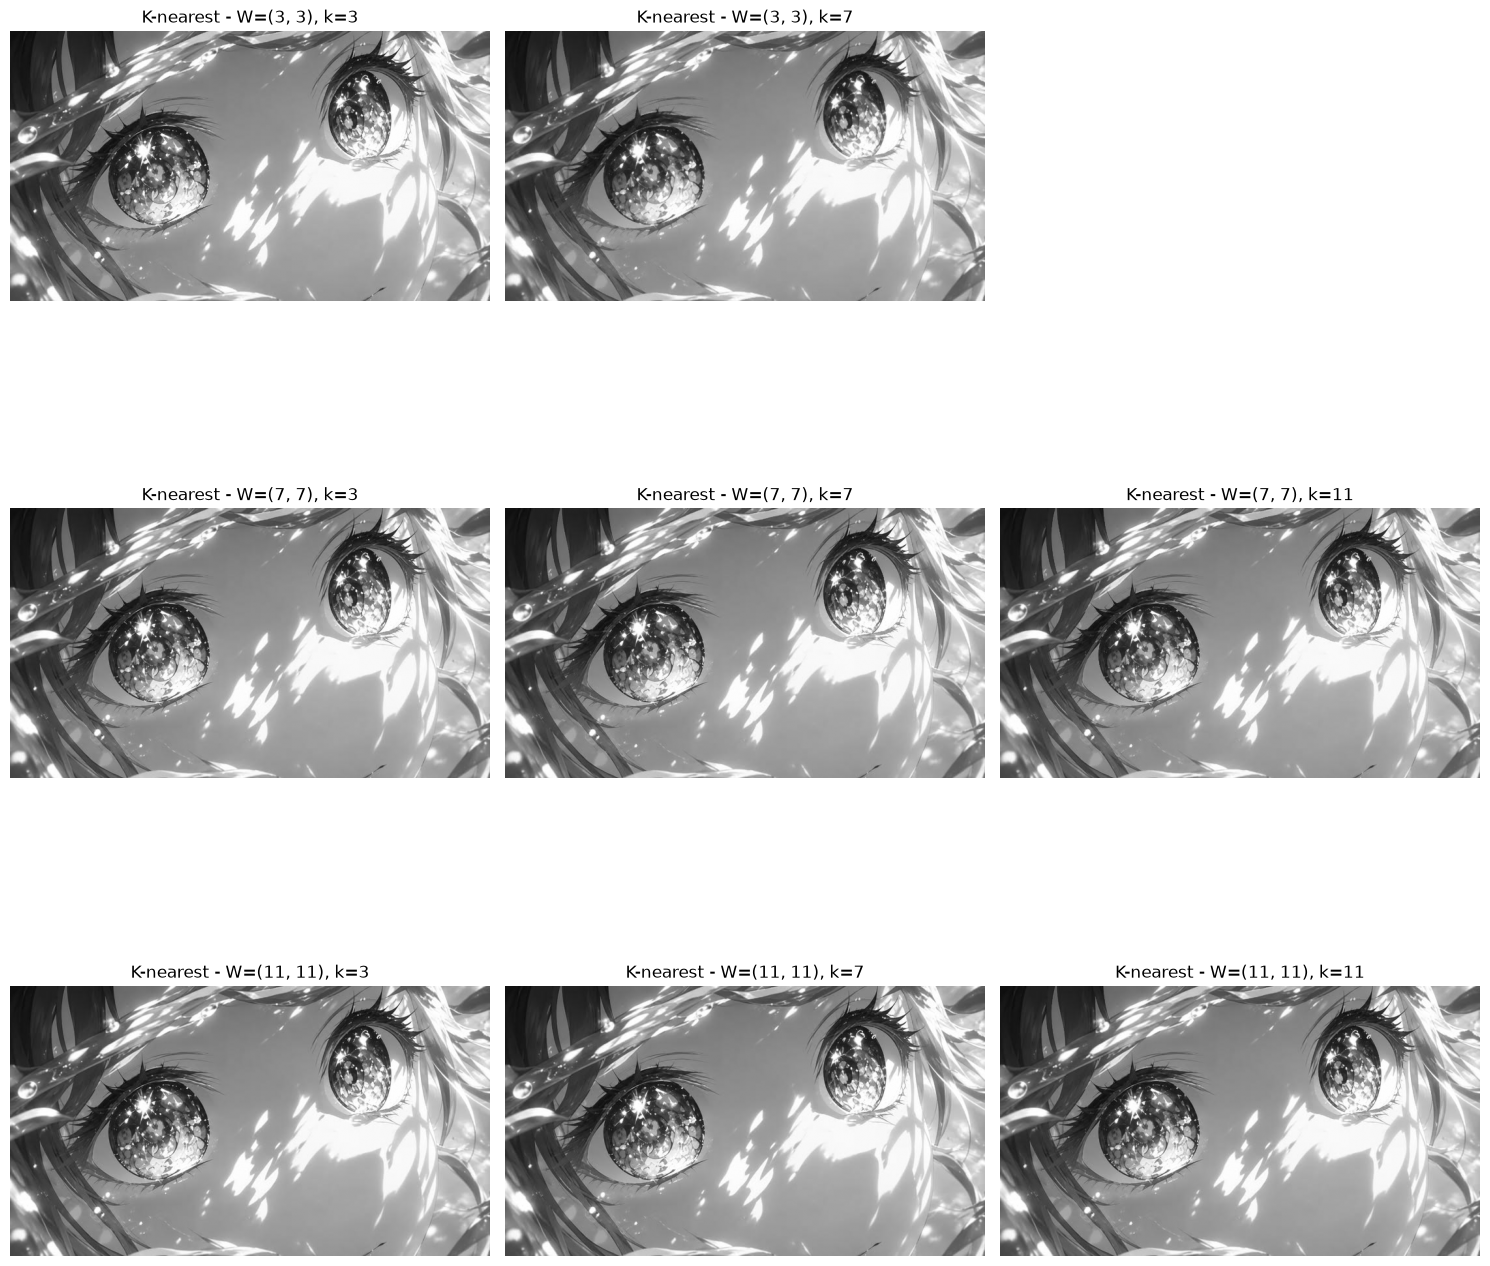

In [8]:
ks = [3, 7, 11]

plt.figure(figsize=(15, 15))
i = 1
for W in Ws:
    for k in ks:
        if k <= W[0] * W[1]:          # W=3x3 chỉ có 9 điểm nên bỏ k=11
            kq = loc_trung_binh_k_gan_nhat(img_gray, W=W, k=k, theta=5)
            plt.subplot(3, 3, i)
            plt.imshow(kq, cmap="gray", vmin=0, vmax=255)
            plt.title(f"K-nearest - W={W}, k={k}")
            plt.axis("off")
        i += 1

plt.tight_layout()
plt.show()

### Lọc trung vị

In [9]:
def trung_vi(x0, y0, I, W):
    h, w = W[0], W[1]
    dy, dx = h // 2, w // 2
    x, y = x0 - dx, y0 - dy

    values = []
    for i in range(y, y + h):
        for j in range(x, x + w):
            values.append(int(I[i, j]))

    values.sort()
    return values[len(values) // 2]


def loc_trung_vi(I, W=(3, 3), theta=1):
    wh, ww = W[0], W[1]
    dy, dx = wh // 2, ww // 2

    I_kq = np.copy(I)
    for y in range(dy, I.shape[0] - dy):
        for x in range(dx, I.shape[1] - dx):
            med = trung_vi(x, y, I, W)
            if abs(int(I[y, x]) - int(med)) > theta:
                I_kq[y, x] = med

    return I_kq

In [ ]:
plt.figure(figsize=(15, 15))
i = 1
for W in Ws:
    for theta in thetas:
        kq = loc_trung_vi(img_gray, W=W, theta=theta)
        plt.subplot(3, 3, i)
        plt.imshow(kq, cmap="gray", vmin=0, vmax=255)
        plt.title(f"Median - W={W}, θ={theta}")
        plt.axis("off")
        i += 1

plt.tight_layout()
plt.show()

## b. Cuộn với nhân Gauss 2 chiều

In [ ]:
def gaussian_kernel(size, sigma):
    k = size // 2
    x, y = np.meshgrid(np.arange(-k, k + 1), np.arange(-k, k + 1))
    kernel = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    kernel = kernel / np.sum(kernel)
    return kernel


def gaussian_filter(I, size, sigma):
    kernel = gaussian_kernel(size, sigma)
    return cv.filter2D(I, -1, kernel)

In [ ]:
params = [
    (3, 0.5),
    (7, 1.5),
    (11, 3.0)
]

results = []
for size, sigma in params:
    results.append(gaussian_filter(img_gray, size, sigma))

plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.imshow(img_gray, cmap="gray")
plt.title("Ảnh gốc")
plt.axis("off")

for i, ((size, sigma), img) in enumerate(zip(params, results), 2):
    plt.subplot(1, 4, i)
    plt.imshow(img, cmap="gray")
    plt.title(f"size={size}, σ={sigma}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## c. Phát hiện chuyển động trong video giao thông
- Input: video, ngưỡng T, số khung n, chọn trung bình hoặc trung vị
- Output: video mới (trắng = chuyển động, đen = nền)

In [3]:
def phat_hien_chuyen_dong(video_in, video_out, T=30, n=10, mode="mean"):
    cap = cv.VideoCapture(video_in)
    if not cap.isOpened():
        raise FileNotFoundError(f"Không mở được video: {video_in}")

    w = int(cap.get(cv.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv.CAP_PROP_FPS)
    if fps == 0:
        fps = 25

    out = cv.VideoWriter(video_out, cv.VideoWriter_fourcc(*"mp4v"), fps, (w, h), False)

    frames = []                                   # n khung hình gần nhất
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        Ic = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)

        frames.append(Ic)
        if len(frames) > n:
            frames.pop(0)                         # bỏ khung cũ nhất

        stack = np.array(frames)
        if mode == "mean":
            B = np.mean(stack, axis=0)            # ảnh nền: trung bình
        else:
            B = np.median(stack, axis=0)          # ảnh nền: trung vị

        diff = np.abs(Ic.astype(np.float32) - B)
        mask = np.where(diff > T, 255, 0).astype(np.uint8)

        out.write(mask)

    cap.release()
    out.release()
    print("Xong:", video_out)

In [4]:
video_path = "video.mp4"

phat_hien_chuyen_dong(video_path, "out_mean.mp4", T=30, n=10, mode="mean")
phat_hien_chuyen_dong(video_path, "out_median.mp4", T=30, n=10, mode="median")

Xong: out_mean.mp4


KeyboardInterrupt: 